# Notebook 5 — Comparative Statics

This notebook sweeps over key model parameters to understand how they affect:
- Bubble existence (leakage sum $\sum a_t$)
- The exorbitant privilege ($R_f - R^W_f$)
- Portfolio allocations and stock prices

**Parameters swept**:
1. $\chi$ (convenience yield) — controls the exorbitant privilege
2. $\kappa$ (home-bias cost) — controls portfolio distortion
3. $\pi$ (regime persistence) — controls expected bubble duration
4. $\gamma$ (risk aversion) — controls condition (2b)
5. $g_{D,u}$ (US dividend growth) — controls condition (2a)

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Local_git/Open_HKT`


Plots.GRBackend()

In [2]:
# ── Helper: run simulation and extract key statistics ──
function run_and_summarize(p::ModelParams)
    try
        res = run_simulation(p; verbose=false)
        s0 = res.u_path[1]
        d  = res.diagnostics
        return (
            converged = true,
            ω_0       = s0.ω,
            ω_star_0  = s0.ω_star,
            θ_0       = s0.θ,
            θ_Us_0    = s0.θ_US_star,
            R_f_0     = s0.R_f,
            R_f_W_0   = s0.R_f_W,
            ep_0      = s0.R_f - s0.R_f_W,
            Q_US_0    = s0.Q_US,
            Q_W_0     = s0.Q_W,
            us_share  = s0.Q_US / (s0.Q_US + s0.Q_W),
            sum_at    = d.sum_a_t[end],
            sum_2a    = d.sum_dividend_ratio[end],
            sum_2b    = d.sum_cond_2b[end],
            bubble    = d.bubble_exists,
            result    = res
        )
    catch e
        @warn "Simulation failed" p e
        return (converged=false, ω_0=NaN, ω_star_0=NaN, θ_0=NaN, θ_Us_0=NaN,
                R_f_0=NaN, R_f_W_0=NaN, ep_0=NaN, Q_US_0=NaN, Q_W_0=NaN,
                us_share=NaN, sum_at=NaN, sum_2a=NaN, sum_2b=NaN,
                bubble=false, result=nothing)
    end
end;

## 1. Sweep over $\chi$ (Convenience Yield)

$\chi$ controls the RoW's demand for US bonds. Higher $\chi$ means:
- Stronger "exorbitant privilege" ($R_f - R^W_f$ larger)
- More US borrowing ($\theta$ more negative)
- Potentially affects bubble existence through the equity share channel

In [3]:
chi_vals = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
chi_results = [run_and_summarize(ModelParams(χ=v)) for v in chi_vals]

println("\n══ χ Sweep Results ══")
println("   χ       R_f    R_f_W   EP      θ₀       Σaₜ      Bubble")
for (v, r) in zip(chi_vals, chi_results)
    r.converged || continue
    @printf("  %.3f   %.4f  %.4f  %+.4f  %+.6f  %.4f    %s\n",
            v, r.R_f_0, r.R_f_W_0, r.ep_0, r.θ_0, r.sum_at, r.bubble)
end


══ χ Sweep Results ══
   χ       R_f    R_f_W   EP      θ₀       Σaₜ      Bubble
  0.005   1.2213  1.2340  -0.0127  -0.969990  54.0323    false
  0.010   1.2134  1.2335  -0.0201  -1.215464  54.0392    false
  0.020   1.2018  1.2326  -0.0308  -1.569335  54.0442    false
  0.030   1.1928  1.2319  -0.0391  -1.836100  54.0454    false
  0.050   1.1782  1.2306  -0.0523  -2.240447  54.0457    false
  0.080   1.1608  1.2288  -0.0680  -2.677269  54.0479    false
  0.100   1.1508  1.2277  -0.0769  -2.903006  54.0513    false


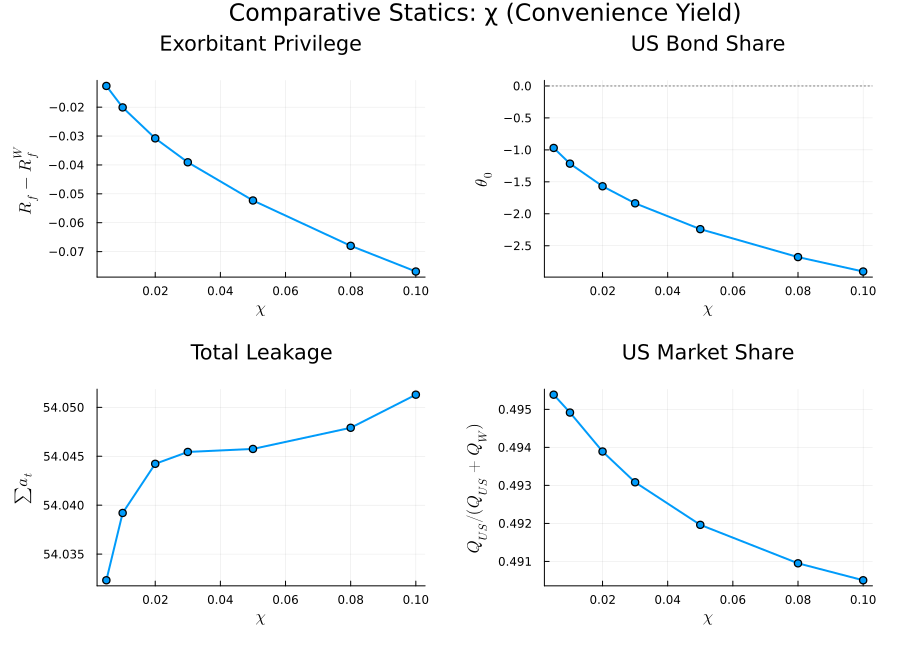

In [4]:
mask = [r.converged for r in chi_results]
xv = chi_vals[mask]

cp1 = plot(xv, [r.ep_0 for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"R_f - R^W_f",
           title="Exorbitant Privilege", legend=false)

cp2 = plot(xv, [r.θ_0 for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"\theta_0",
           title="US Bond Share", legend=false)
hline!(cp2, [0.0], ls=:dot, lc=:gray)

cp3 = plot(xv, [r.sum_at for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

cp4 = plot(xv, [r.us_share for r in chi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\chi", ylabel=L"Q_{US}/(Q_{US}+Q_W)",
           title="US Market Share", legend=false)

plot(cp1, cp2, cp3, cp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: χ (Convenience Yield)")

## 2. Sweep over $\kappa$ (Home-Bias Cost)

$\kappa$ penalises deviations from the home-bias target. Higher $\kappa$:
- Keeps portfolio weights closer to targets ($\bar\omega$, $\bar\omega^*$)
- Increases the effective return wedge between US and RoW equities
- Must satisfy Lemma 1: $\kappa < \beta/\bar\omega$

In [ ]:
kappa_max = 0.5 * 0.625  # well below beta/omega_bar = 0.625
kappa_vals = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
kappa_results = [run_and_summarize(ModelParams(κ=v)) for v in kappa_vals]

println("\n══ κ Sweep Results ══")
println("   κ       ω₀     ω*₀    R_f     Σaₜ      Bubble")
for (v, r) in zip(kappa_vals, kappa_results)
    r.converged || continue
    @printf("  %.3f   %.4f  %.4f  %.4f  %.4f    %s\n",
            v, r.ω_0, r.ω_star_0, r.R_f_0, r.sum_at, r.bubble)
end

In [ ]:
mask = [r.converged for r in kappa_results]
xv = kappa_vals[mask]

kp1 = plot(xv, [r.ω_0 for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\omega_0",
           title="US Portfolio Weight", legend=false)
hline!(kp1, [0.80], ls=:dot, lc=:gray)

kp2 = plot(xv, [r.ω_star_0 for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\omega^*_0",
           title="RoW US-Equity Weight", legend=false)
hline!(kp2, [0.20], ls=:dot, lc=:gray)

kp3 = plot(xv, [r.sum_at for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

kp4 = plot(xv, [r.us_share for r in kappa_results[mask]], lw=2, marker=:circle,
           xlabel=L"\kappa", ylabel=L"Q_{US}/(Q_{US}+Q_W)",
           title="US Market Share", legend=false)

plot(kp1, kp2, kp3, kp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: κ (Home-Bias Cost)")

## 3. Sweep over $\pi$ (Regime Persistence)

$\pi$ is the probability of staying in unbalanced growth. Higher $\pi$:
- Longer expected bubble duration ($E[\tau] = 1/(1-\pi)$)
- Makes the switch leakage term smaller (less probability mass on switching)
- Should make bubbles more likely to exist

In [ ]:
pi_vals = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
pi_results = [run_and_summarize(ModelParams(π_persist=v)) for v in pi_vals]

println("\n══ π Sweep Results ══")
println("   π     E[τ]   R_f     EP      Σaₜ       Bubble")
for (v, r) in zip(pi_vals, pi_results)
    r.converged || continue
    @printf("  %.2f   %5.1f  %.4f  %+.4f  %8.4f    %s\n",
            v, 1/(1-v), r.R_f_0, r.ep_0, r.sum_at, r.bubble)
end

In [ ]:
mask = [r.converged for r in pi_results]
xv = pi_vals[mask]

pp1 = plot(xv, [r.R_f_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"R_{f,0}",
           title="Risk-Free Rate", legend=false)

pp2 = plot(xv, [r.ep_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"R_f - R^W_f",
           title="Exorbitant Privilege", legend=false)

pp3 = plot(xv, [r.sum_at for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

pp4 = plot(xv, [r.θ_0 for r in pi_results[mask]], lw=2, marker=:circle,
           xlabel=L"\pi", ylabel=L"\theta_0",
           title="US Bond Share", legend=false)
hline!(pp4, [0.0], ls=:dot, lc=:gray)

plot(pp1, pp2, pp3, pp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: π (Regime Persistence)")

## 4. Sweep over $\gamma$ (Risk Aversion)

$\gamma$ controls condition (2b): $\sum (C^b/C^u)^{1-\gamma}$.
- For $\gamma > 1$ and $C^u > C^b$: the term $(C^b/C^u)^{1-\gamma} = (C^b/C^u)^{-(\gamma-1)}$ is large, making convergence harder.
- For $\gamma > 1$ and $C^u < C^b$: the term is small and convergence is easy.
- Higher $\gamma$ also affects portfolio allocations and the equity premium.

In [ ]:
gamma_vals = [1.5, 2.0, 3.0, 4.0, 5.0]
gamma_results = [run_and_summarize(ModelParams(γ=v)) for v in gamma_vals]

println("\n══ γ Sweep Results ══")
println("   γ     R_f     EP       Σ(2b)     Σaₜ      Bubble")
for (v, r) in zip(gamma_vals, gamma_results)
    r.converged || continue
    @printf("  %.1f   %.4f  %+.4f  %8.4f  %8.4f    %s\n",
            v, r.R_f_0, r.ep_0, r.sum_2b, r.sum_at, r.bubble)
end

In [ ]:
mask = [r.converged for r in gamma_results]
xv = gamma_vals[mask]

gp1 = plot(xv, [r.sum_2b for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\sum (C^b/C^u)^{1-\gamma}",
           title="Condition (2b) Sum", legend=false)

gp2 = plot(xv, [r.sum_at for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\sum a_t",
           title="Total Leakage", legend=false)

gp3 = plot(xv, [r.ω_0 for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"\omega_0",
           title="US Portfolio Weight", legend=false)

gp4 = plot(xv, [r.R_f_0 for r in gamma_results[mask]], lw=2, marker=:circle,
           xlabel=L"\gamma", ylabel=L"R_{f,0}",
           title="Risk-Free Rate", legend=false)

plot(gp1, gp2, gp3, gp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: γ (Risk Aversion)")

## 5. Sweep over $g_{D,u}$ (US Dividend Growth)

The gap between $g_{D,u}$ and $g_{e,u}$ is the primary driver of condition (2a).
- When $g_{D,u} \to g_{e,u}$: $D/e$ stays constant, sum diverges, no bubble.
- When $g_{D,u} \ll g_{e,u}$: $D/e \to 0$ quickly, strong bubble conditions.

In [ ]:
# Annual growth rates for dividends
gD_annual = [0.005, 0.010, 0.012, 0.015, 0.020, 0.025, 0.030]
gD_vals = [(1.0 + g)^5 for g in gD_annual]   # per-period (5 years)

gD_results = [run_and_summarize(ModelParams(g_D_u=v)) for v in gD_vals]

println("\n══ g_D Sweep Results ══")
println("  g_D(ann)  g_D(5yr)  g_D/g_e   Σ(2a)      Σaₜ       Bubble")
for (ga, v, r) in zip(gD_annual, gD_vals, gD_results)
    r.converged || continue
    @printf("  %.3f    %.4f   %.4f   %9.4f  %9.4f    %s\n",
            ga, v, v / ModelParams().g_e_u, r.sum_2a, r.sum_at, r.bubble)
end

In [ ]:
mask = [r.converged for r in gD_results]
xv = gD_annual[mask]

gdp1 = plot(xv, [r.sum_2a for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"\sum D^u/e^u",
            title="Condition (2a) Sum", legend=false)

gdp2 = plot(xv, [r.sum_at for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"\sum a_t",
            title="Total Leakage", legend=false)

# Bubble share at t=1 (if available)
bshare = Float64[]
for r in gD_results[mask]
    if r.result !== nothing
        push!(bshare, r.Q_US_0)  # placeholder; actual share needs V computation
    else
        push!(bshare, NaN)
    end
end

gdp3 = plot(xv, [r.R_f_0 for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel=L"R_{f,0}",
            title="Risk-Free Rate", legend=false)

gdp4 = plot(xv, [r.us_share for r in gD_results[mask]], lw=2, marker=:circle,
            xlabel=L"g_{D,u}\ (\mathrm{annual})", ylabel="US share",
            title="US Market Cap Share", legend=false)

plot(gdp1, gdp2, gdp3, gdp4, layout=(2,2), size=(900, 650), margin=5Plots.mm,
     plot_title="Comparative Statics: g_{D,u} (Dividend Growth)")

## 6. Summary Table

Collecting the key finding from each sweep.

In [5]:
println("\n══════════════════════════════════════════════════════")
println("        COMPARATIVE STATICS SUMMARY")
println("══════════════════════════════════════════════════════")
println()
println("χ (convenience yield):")
println("  ↑ χ  ⟹  ↑ exorbitant privilege, ↑ US borrowing")
println()
println("κ (home-bias cost):")
println("  ↑ κ  ⟹  portfolio closer to targets, affects return wedge")
println()
println("π (regime persistence):")
println("  ↑ π  ⟹  longer bubble episodes, affects leakage via switch probability")
println()
println("γ (risk aversion):")
println("  ↑ γ  ⟹  affects condition (2b) summability and equity premium")
println()
println("g_D,u (dividend growth):")
println("  ↓ g_D  ⟹  faster D/e decay, easier bubble formation (cond 2a)")
println("  g_D → g_e ⟹  no bubble (cond 2a fails)")


══════════════════════════════════════════════════════
        COMPARATIVE STATICS SUMMARY
══════════════════════════════════════════════════════

χ (convenience yield):
  ↑ χ  ⟹  ↑ exorbitant privilege, ↑ US borrowing

κ (home-bias cost):
  ↑ κ  ⟹  portfolio closer to targets, affects return wedge

π (regime persistence):
  ↑ π  ⟹  longer bubble episodes, affects leakage via switch probability

γ (risk aversion):
  ↑ γ  ⟹  affects condition (2b) summability and equity premium

g_D,u (dividend growth):
  ↓ g_D  ⟹  faster D/e decay, easier bubble formation (cond 2a)
  g_D → g_e ⟹  no bubble (cond 2a fails)


## Summary

The comparative statics confirm the model's key mechanisms:

1. **Convenience yield $\chi$**: Directly controls the exorbitant privilege and US net borrowing. Higher $\chi$ strengthens the US's ability to borrow cheaply, which can amplify bubble dynamics.

2. **Home-bias cost $\kappa$**: Keeps portfolios near their targets. Small $\kappa$ allows more portfolio adjustment, potentially affecting the effective pricing kernel.

3. **Regime persistence $\pi$**: Higher $\pi$ means longer expected unbalanced growth episodes. This directly affects the leakage ratio through the $(1-\pi)/\pi$ factor in the switch term.

4. **Risk aversion $\gamma$**: Affects condition (2b) through the power $(1-\gamma)$. With $\gamma > 1$, the consumption ratio term can grow or shrink depending on whether the switch improves or worsens consumption.

5. **Dividend growth gap**: The most direct lever for bubble existence. When $g_{D,u} \approx g_{e,u}$, condition (2a) fails and no bubble can exist.